In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parents[0]
DB_PATH = BASE_DIR / "data" / "mart" / "olist.duckdb"

conn = duckdb.connect(str(DB_PATH))

In [2]:
query = """
SELECT
    COALESCE(product_category_name_english, product_category_name) AS category,
    COUNT(*) AS total_items_sold,
    AVG(price) AS avg_price,
    AVG(review_score) AS avg_review
FROM mart_order_items
GROUP BY 1
ORDER BY total_items_sold DESC
LIMIT 15
"""

df_categories = conn.execute(query).fetchdf()
df_categories

,category,total_items_sold,avg_price,avg_review
0,bed_bath_table,11270,93.250808,3.895663
1,health_beauty,9727,129.859005,4.142768
2,sports_leisure,8700,114.213392,4.107986
3,furniture_decor,8415,87.496431,3.903493
4,computers_accessories,7894,116.498675,3.930819
5,housewares,6989,90.791615,4.055019
6,watches_gifts,6001,200.979058,4.019160
7,telephony,4550,71.173495,3.946867
8,garden_tools,4361,111.541493,4.042735
9,auto,4256,139.652984,4.065512


**EDA**


**Top Categorías**

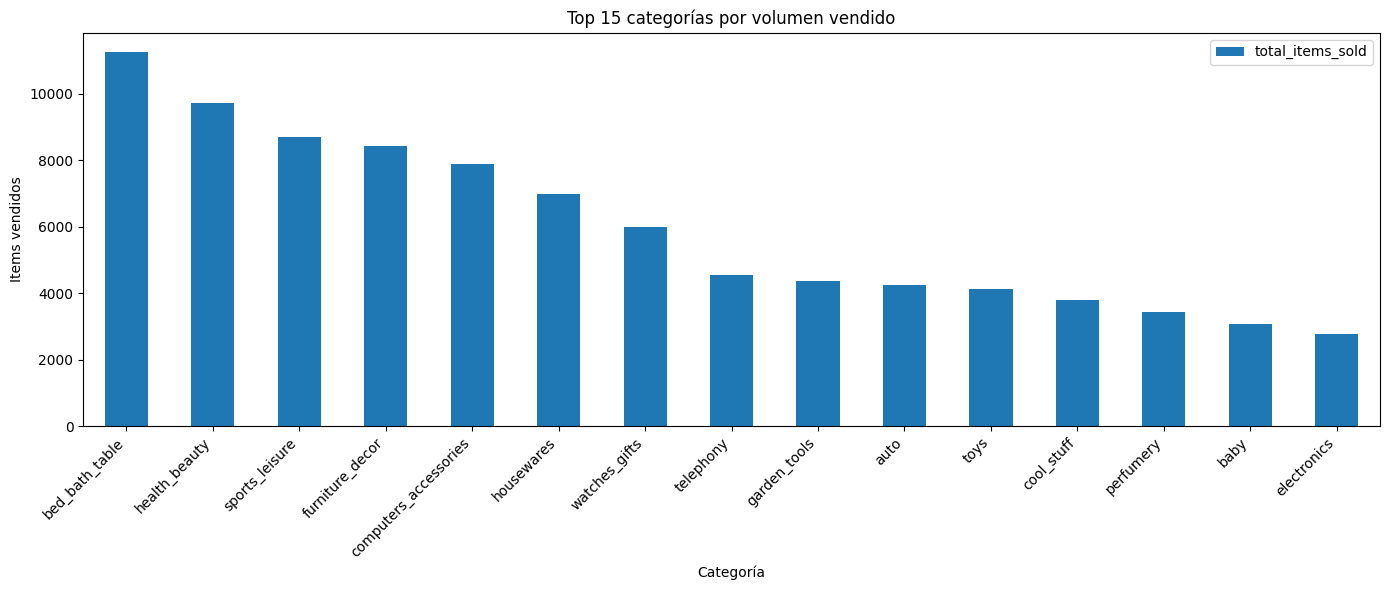

In [3]:
df_categories.plot(
    x="category",
    y="total_items_sold",
    kind="bar",
    figsize=(14, 6)
)
plt.title("Top 15 categorías por volumen vendido")
plt.ylabel("Items vendidos")
plt.xlabel("Categoría")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Lectura de negocio

* Hay categorías “motor” del negocio por volumen: bed_bath_table, health_beauty, sports_leisure.
* Hay categorías con riesgo reputacional dentro del top por su menor review: bed_bath_table, furniture_decor, computers_accessories.
* Hay categorías con señal de oportunidad: toys, perfumery y cool_stuff, porque tienen buena satisfacción y podrían escalar con más visibilidad o inversión comercial.

**review vs precio**

In [4]:
query = """
SELECT
    COALESCE(product_category_name_english, product_category_name) AS category,
    COUNT(*) AS total_items_sold,
    AVG(price) AS avg_price,
    AVG(review_score) AS avg_review
FROM mart_order_items
WHERE review_score IS NOT NULL
GROUP BY 1
HAVING COUNT(*) >= 100
"""

df_review_price = conn.execute(query).fetchdf()
df_review_price.head()

,category,total_items_sold,avg_price,avg_review
0,bed_bath_table,11137,93.395018,3.895663
1,sports_leisure,8640,114.218625,4.107986
2,stationery,2507,91.677615,4.193857
3,home_appliances,806,102.945099,4.172457
4,books_general_interest,549,84.845410,4.446266


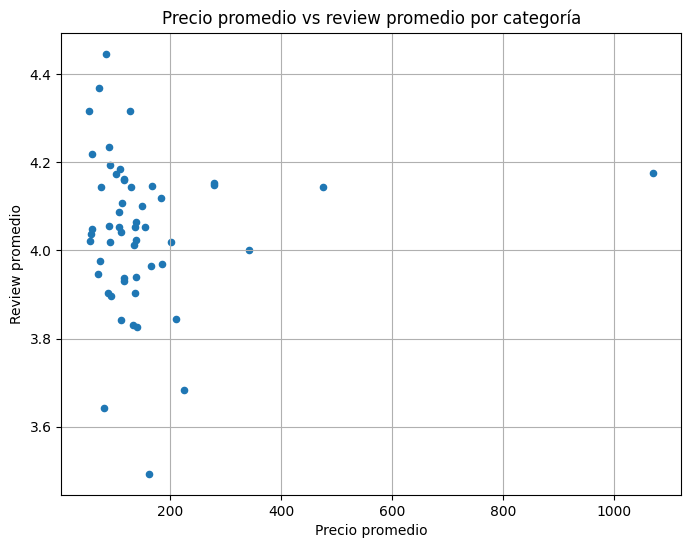

In [5]:
df_review_price.plot(
    x="avg_price",
    y="avg_review",
    kind="scatter",
    figsize=(8, 6)
)
plt.title("Precio promedio vs review promedio por categoría")
plt.xlabel("Precio promedio")
plt.ylabel("Review promedio")
plt.grid(True)
plt.show()

La relación entre precio promedio y review promedio por categoría es débil: categorías más caras no reciben necesariamente mejores valoraciones. De hecho, algunas categorías de precio moderado o bajo, como books_general_interest y stationery, muestran mejores niveles de satisfacción. 
Además, bed_bath_table, pese a liderar en volumen vendido, presenta una valoración relativamente menor, lo que sugiere oportunidades de mejora en experiencia o calidad.

**Porcentaje de atraso por categoría**

In [6]:
query = """
SELECT
    COALESCE(product_category_name_english, product_category_name) AS category,
    COUNT(*) AS total_items,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1
                ELSE 0
            END
        ),
        2
    ) AS late_rate_pct
FROM mart_order_items
WHERE order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
GROUP BY 1
HAVING COUNT(*) >= 100
ORDER BY late_rate_pct DESC
LIMIT 15
"""

df_late = conn.execute(query).fetchdf()
df_late

,category,total_items,late_rate_pct
0,audio,363,12.67
1,fashion_underwear_beach,127,12.60
2,christmas_supplies,150,12.00
3,books_technical,265,10.94
4,home_confort,432,10.19
5,construction_tools_lights,302,9.93
6,food,499,9.82
7,electronics,2730,9.74
8,None,1545,9.32
9,health_beauty,9521,9.06


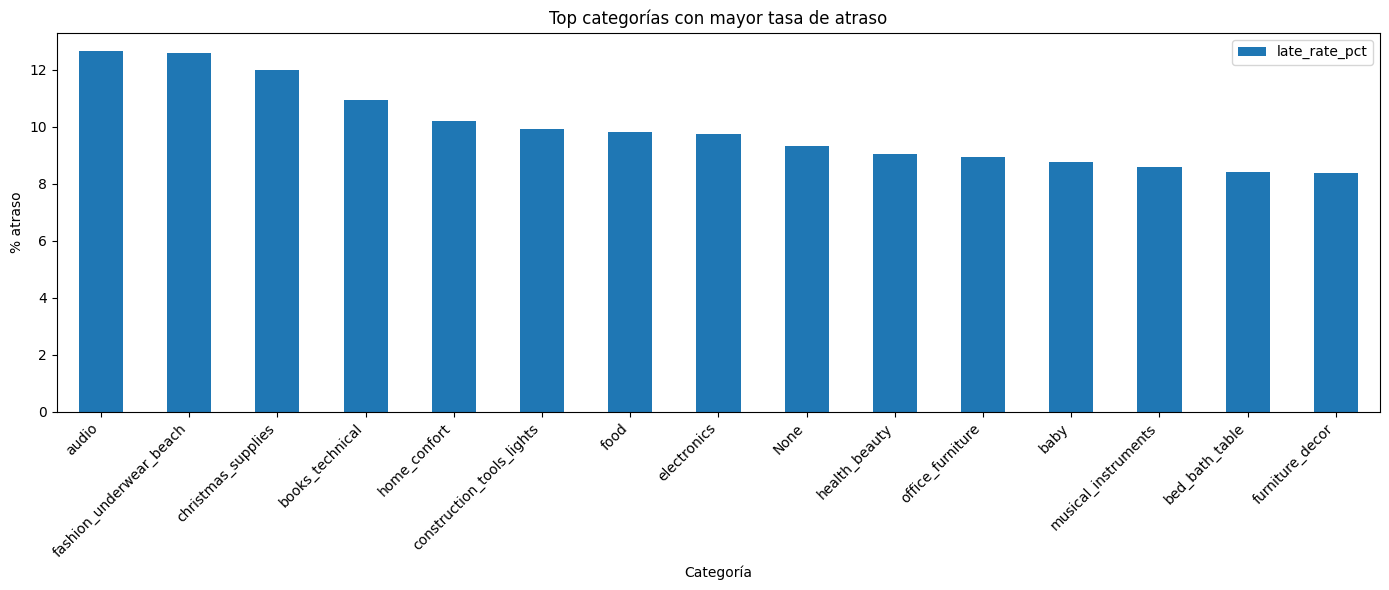

In [7]:
df_late.plot(
    x="category",
    y="late_rate_pct",
    kind="bar",
    figsize=(14, 6)
)
plt.title("Top categorías con mayor tasa de atraso")
plt.ylabel("% atraso")
plt.xlabel("Categoría")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

* Las mayores tasas de atraso se observan en categorías como audio, fashion_underwear_beach y christmas_supplies; sin embargo, su bajo volumen limita su impacto global. 
* En términos de negocio, las categorías más críticas son aquellas que combinan una tasa de atraso relevante con un alto número de pedidos, como health_beauty, bed_bath_table, furniture_decor y electronics, ya que concentran una parte importante de las entregas tardías del marketplace